In [ ]:
print("hello world")

hello world


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import OneCycleLR
import kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, EsmModel

# ESM2 backbone
ESM_MODEL     = "facebook/esm2_t12_35M_UR50D"   # 12 layers, 480-dim, 35M params
MAX_LEN       = 510    # 512 total minus 2 special tokens (<cls> / <eos>)
FREEZE_LAYERS = 6      # freeze first 6 of 12 ESM layers; fine-tune last 6 + head

In [ ]:
path = kagglehub.dataset_download("lzyacht/proteinsubcellularlocalization")

print("Path to dataset files:", path)

100%|██████████| 986k/986k [00:01<00:00, 898kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lzyacht/proteinsubcellularlocalization/versions/1


In [ ]:
cp -r $path 'sample_data'

In [ ]:
df = pd.read_csv('sample_data/1/proteins.csv')
# 1. Check Class Distribution
print("=== CLASS DISTRIBUTION ===")
class_counts = df['label'].value_counts()
print(class_counts)





=== CLASS DISTRIBUTION ===
label
cytoplasmic.fasta        1411
plasma_membrane.fasta    1238
extracellular.fasta       843
nuclear.fasta             837
mitochondrial.fasta       510
chloroplast.fasta         449
ER.fasta                  198
peroxisomal.fasta         157
Golgi.fasta               150
lysosomal.fasta           103
vacuolar.fasta             63
Name: count, dtype: int64


In [ ]:
# 2. Check Sequence Length Distribution
# Calculate the length of each protein string
df['seq_length'] = df['sequence'].apply(len)
print("\n=== SEQUENCE LENGTH STATISTICS ===")
print(df['seq_length'].describe())


=== SEQUENCE LENGTH STATISTICS ===
count    5959.000000
mean      326.276221
std       289.521856
min         9.000000
25%       151.000000
50%       258.000000
75%       403.000000
max      3678.000000
Name: seq_length, dtype: float64


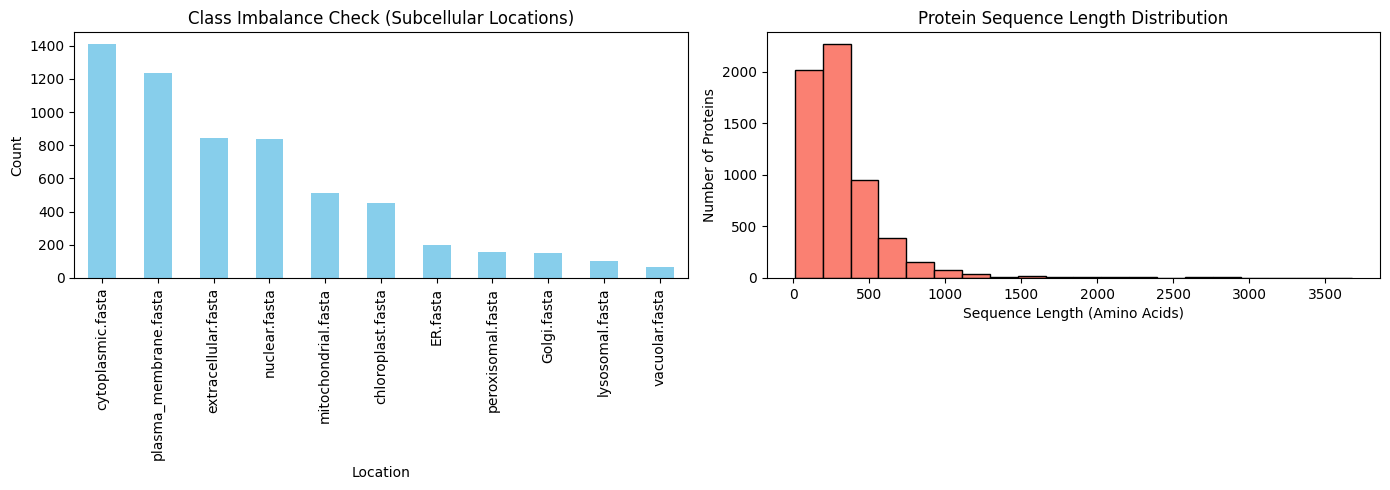

In [ ]:
# 3. Visualizations (Plots will render directly in your notebook)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Class Counts
class_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Class Imbalance Check (Subcellular Locations)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Location")

# Plot Sequence Length Histogram
axes[1].hist(df['seq_length'], bins=20, color='salmon', edgecolor='black')
axes[1].set_title("Protein Sequence Length Distribution")
axes[1].set_ylabel("Number of Proteins")
axes[1].set_xlabel("Sequence Length (Amino Acids)")

plt.tight_layout()
plt.show()

In [ ]:
train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, 
    stratify=df['label']
)

# 2. Second split: Break the remaining 30% into equal Validation and Test sets (15% each)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_df['label']
)

In [ ]:
class ProteinDatasetESM(Dataset):
    """Returns raw sequence strings — ESM tokenizer handles encoding in the collate fn."""
    def __init__(self, dataframe, label_to_int, max_len=510):
        self.df           = dataframe.reset_index(drop=True)
        self.label_to_int = label_to_int
        self.max_len      = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        seq   = row['sequence'][:self.max_len]   # truncate before tokenizer adds special tokens
        label = self.label_to_int[row['label']]
        return seq, torch.tensor(label)

In [ ]:
def esm_collate(batch):
    """Batch-tokenize sequences with the ESM tokenizer; pad to longest in batch."""
    seqs   = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])
    encoded = tokenizer(
        seqs,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512,
    )
    return encoded['input_ids'], encoded['attention_mask'], labels

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL)

master_label_map = {label: i for i, label in enumerate(df['label'].unique())}
NUM_CLASSES      = len(master_label_map)

train_dataset = ProteinDatasetESM(train_df, master_label_map, max_len=MAX_LEN)
val_dataset   = ProteinDatasetESM(val_df,   master_label_map, max_len=MAX_LEN)
test_dataset  = ProteinDatasetESM(test_df,  master_label_map, max_len=MAX_LEN)

# WeightedRandomSampler: give every class an equal shot in every batch
# This is the primary fix for class collapse (model defaulting to cytoplasmic)
label_counts   = train_df['label'].value_counts()
sample_weights = train_df['label'].map(lambda l: 1.0 / label_counts[l]).values
sampler        = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(train_dataset),
    replacement=True,
)

# sampler is mutually exclusive with shuffle=True
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler,  collate_fn=esm_collate)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,    collate_fn=esm_collate)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,    collate_fn=esm_collate)

print(f"Classes: {NUM_CLASSES}  |  Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")

Classes: 11  |  Train: 4171  Val: 894  Test: 894


In [ ]:
input_ids, attention_mask, batch_labels = next(iter(train_loader))

print("=== PIPELINE CHECK ===")
print(f"input_ids shape:      {input_ids.shape}      -> (batch_size, padded_seq_len)")
print(f"attention_mask shape: {attention_mask.shape} -> (batch_size, padded_seq_len)")
print(f"labels shape:         {batch_labels.shape}   -> (batch_size,)")
print(f"\nFirst sequence (decoded): {tokenizer.decode(input_ids[0], skip_special_tokens=True)[:60]}...")

=== PIPELINE CHECK ===
input_ids shape:      torch.Size([16, 512])      -> (batch_size, padded_seq_len)
attention_mask shape: torch.Size([16, 512]) -> (batch_size, padded_seq_len)
labels shape:         torch.Size([16])   -> (batch_size,)

First sequence (decoded): M R T D W N C A V V G T T S R T V Y D S T Y S V Y K D R N Y ...


In [ ]:
class ESMClassifier(nn.Module):
    """
    ESM2 backbone + lightweight classification head.
    - Freezes the embedding layer and the first `freeze_layers` encoder blocks.
    - Fine-tunes the remaining encoder layers and the classification head.
    - Uses the <cls> token (position 0) as the sequence representation.
    """
    def __init__(self, model_name, num_classes, freeze_layers=6):
        super().__init__()
        self.esm = EsmModel.from_pretrained(model_name)

        # Freeze embedding layer
        for param in self.esm.embeddings.parameters():
            param.requires_grad = False

        # Freeze first `freeze_layers` transformer blocks
        for i, layer in enumerate(self.esm.encoder.layer):
            if i < freeze_layers:
                for param in layer.parameters():
                    param.requires_grad = False

        hidden_size = self.esm.config.hidden_size   # 480 for esm2_t12_35M_UR50D

        # Dropout 0.3 to combat the train/val loss gap (overfitting)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        cls_out = outputs.last_hidden_state[:, 0]   # <cls> token → [batch, hidden]
        return self.classifier(cls_out)

## ESM2 Transfer Learning Classifier

In [ ]:
model = ESMClassifier(ESM_MODEL, NUM_CLASSES, freeze_layers=FREEZE_LAYERS)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100 * trainable / total:.1f}%)")

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 16,864,572 / 33,506,652  (50.3%)


In [ ]:
model.eval()
with torch.no_grad():
    _ids, _mask, _ = next(iter(train_loader))
    predictions = model(_ids, _mask)

print(f"Input IDs shape:     {_ids.shape}")
print(f"Output logits shape: {predictions.shape}  -> (batch_size={predictions.shape[0]}, num_classes={predictions.shape[1]})")

Input IDs shape:     torch.Size([16, 512])
Output logits shape: torch.Size([16, 11])  -> (batch_size=16, num_classes=11)


In [ ]:
# 1. Setup Device (Use GPU if available, otherwise CPU)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
EPOCHS = 50

class_weights  = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label'],
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion      = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

# Differential learning rates:
#   backbone  → 3e-5  (bumped from 1e-5 — backbone needs stronger signal)
#   head      → 1e-3  (randomly initialised; train normally)
optimizer = optim.AdamW([
    {'params': model.esm.parameters(),        'lr': 3e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=0.01)

scheduler = OneCycleLR(
    optimizer,
    max_lr=[3e-5, 1e-3],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,   # 10% warmup
)

In [ ]:
best_val_acc     = 0.0   # ← track accuracy, not loss
patience         = 10
patience_counter = 0

for epoch in range(EPOCHS):
    # ── TRAINING ────────────────────────────────────────────────────────────
    model.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for input_ids, attention_mask, batch_labels in train_bar:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        batch_labels   = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss    = criterion(outputs, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)

    # ── VALIDATION ──────────────────────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for input_ids, attention_mask, batch_labels in val_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            batch_labels   = batch_labels.to(device)

            outputs = model(input_ids, attention_mask)
            loss    = criterion(outputs, batch_labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total   += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = (correct / total) * 100

    print(f"\n=> Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    # ── EARLY STOPPING + CHECKPOINT (tracked by val accuracy) ───────────────
    if val_accuracy > best_val_acc:
        best_val_acc     = val_accuracy
        patience_counter = 0
        # Save full checkpoint: weights + everything needed to reload for inference
        torch.save({
            'epoch':            epoch + 1,
            'model_state_dict': model.state_dict(),
            'val_accuracy':     best_val_acc,
            'master_label_map': master_label_map,
            'esm_model':        ESM_MODEL,
            'freeze_layers':    FREEZE_LAYERS,
            'num_classes':      NUM_CLASSES,
        }, 'best_esm_model.pt')
        print(f"   ✓ Best model saved  (val acc: {best_val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

print("\nTraining complete!")

In [ ]:
from sklearn.metrics import classification_report

# Load best checkpoint (full dict with metadata)
checkpoint = torch.load('best_esm_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  (val acc: {checkpoint['val_accuracy']:.2f}%)")
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        preds = model(input_ids, attention_mask).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

int_to_label = {v: k for k, v in master_label_map.items()}
print(classification_report(
    all_labels, all_preds,
    target_names=[int_to_label[i] for i in range(NUM_CLASSES)],
))

## How to reload the model for inference

In [ ]:
from transformers import AutoTokenizer, EsmModel

def load_model(checkpoint_path: str, device=None):
    """
    Reload the trained ESMClassifier from a checkpoint for inference.

    Usage:
        model, tokenizer, int_to_label = load_model('best_esm_model.pt')
        pred = predict(model, tokenizer, int_to_label, "MKTAYIAKQRQISFVKSHFSRQ...")
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ckpt = torch.load(checkpoint_path, map_location=device)

    model = ESMClassifier(
        model_name    = ckpt['esm_model'],
        num_classes   = ckpt['num_classes'],
        freeze_layers = ckpt['freeze_layers'],
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device)
    model.eval()

    tokenizer    = AutoTokenizer.from_pretrained(ckpt['esm_model'])
    int_to_label = {v: k for k, v in ckpt['master_label_map'].items()}

    print(f"Loaded model from epoch {ckpt['epoch']}  (val acc: {ckpt['val_accuracy']:.2f}%)")
    return model, tokenizer, int_to_label


def predict(model, tokenizer, int_to_label: dict, sequence: str, device=None) -> str:
    """Predict the subcellular location for a single amino acid sequence string."""
    if device is None:
        device = next(model.parameters()).device

    encoded = tokenizer(
        sequence[:510],
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512,
    )
    input_ids      = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        pred   = logits.argmax(dim=1).item()

    return int_to_label[pred]


# ── Quick demo ────────────────────────────────────────────────────────────────
model_inf, tok_inf, i2l = load_model('best_esm_model.pt')

example_seq = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVKVKALPDAQFEVVHSLAKWKRQTLGQHDFSAGEGLYTHMKALRPDEDRLSPLHSVYVDQWDWERVMGDGERQFSTLKSTVEAIWAGIKATEAAVSEEFGLAPFLPDQIHFVHSQELLSRYPDLDAKGRERAIAKDLGAVFLVGIGGKLSDGHRHDVRAPDYDDWSTPSELGHAGLNGDILVWNPVLEDAFELSSMGIRVDADTLKHQLALTGEDEDTOKENS"[:510]
prediction   = predict(model_inf, tok_inf, i2l, example_seq)
print(f"Predicted location: {prediction}")